Financial data ingestion

In [1]:
import yfinance as yf
import pandas as pd
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
ticker_symbol = "RELIANCE.NS"
# ticker_symbol = "BHARTIARTL.NS"
# ticker_symbol = "AAPL"

if os.path.exists("stock_data.csv"):
    df = pd.read_csv("stock_data.csv", index_col=0, parse_dates=True)
else:
    print("Downloading data")
    df = yf.download(ticker_symbol, period="5y")
    df.columns = df.columns.get_level_values(0)
    df.to_csv("stock_data.csv")

[*********************100%***********************]  1 of 1 completed


In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-03-15,956.241211,974.378430,943.363730,970.365607,16698099
2021-03-16,952.477722,963.994887,950.165234,958.553686,13873801
2021-03-17,931.959961,953.565972,922.777952,951.321487,19210236
2021-03-18,910.988770,945.313525,907.315966,939.917660,20647480
2021-03-19,944.043823,950.323858,899.063466,902.781606,41787429


In [4]:
df = df.sort_index()
df['SMA'] = df['Close'].rolling(window=50).mean()
df.head()

Price,Close,High,Low,Open,Volume,SMA
Date,,,,,,
2021-03-15,956.241211,974.378430,943.363730,970.365607,16698099,NaN
2021-03-16,952.477722,963.994887,950.165234,958.553686,13873801,NaN
2021-03-17,931.959961,953.565972,922.777952,951.321487,19210236,NaN
2021-03-18,910.988770,945.313525,907.315966,939.917660,20647480,NaN
2021-03-19,944.043823,950.323858,899.063466,902.781606,41787429,NaN


In [5]:
df.dropna(inplace=True)

df['Error'] = df['Close'] - df['SMA']
df['Percentage'] = df['Error'].abs() / df['Close']
result = df['Percentage'].mean() * 100
result, df.head(5)

(np.float64(4.299923061237304),
 Price             Close         High         Low         Open    Volume  \
 Date                                                                      
 2021-05-28   949.847778   954.472754  902.328194   902.328194  56469931   
 2021-05-31   979.547546   993.785282  945.426862   953.112488  59124142   
 2021-06-01   983.447083   998.455648  973.290173   982.132103  28013832   
 2021-06-02   998.115540  1001.856347  978.051188   978.051188  24630162   
 2021-06-03  1001.924377  1020.220331  995.780410  1007.070776  23974257   
 
 Price              SMA      Error  Percentage  
 Date                                           
 2021-05-28  898.948334  50.899445    0.053587  
 2021-05-31  899.414460  80.133086    0.081806  
 2021-06-01  900.033848  83.413235    0.084817  
 2021-06-02  901.356959  96.758580    0.096941  
 2021-06-03  903.175671  98.748706    0.098559  )

Analysing data

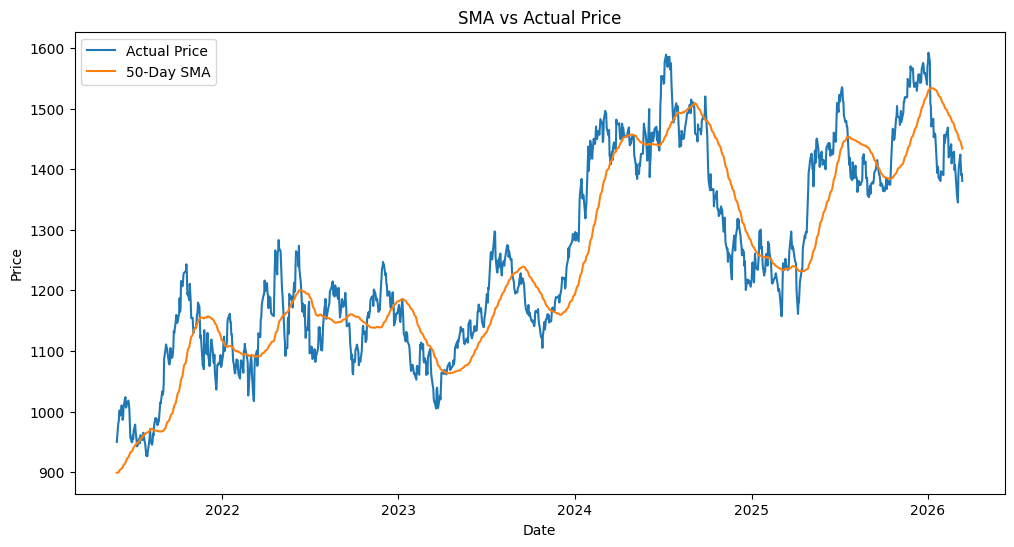

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Actual Price')
plt.plot(df.index, df['SMA'], label='50-Day SMA')
plt.title('SMA vs Actual Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

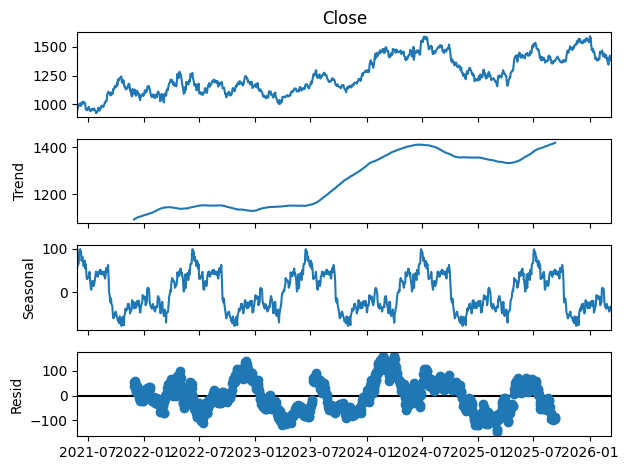

In [7]:
decomposition = seasonal_decompose(df['Close'], model='additive', period=252)
decomposition.plot()
plt.show()

In [8]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'SMA', 'Error', 'Percentage'], dtype='object', name='Price')

In [9]:
adf_res = adfuller(df['Close'])
adf_res[1]

np.float64(0.1827424805600198)

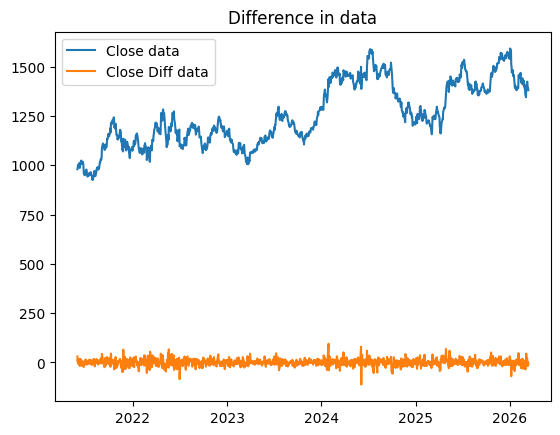

(None, 0.0)

In [10]:
df["Close_Diff"] = df["Close"].diff()
df.dropna(inplace=True)
adf_res_new = adfuller(df['Close_Diff'])
# adf_res_new[1]
plt.plot(df.index, df["Close"], label="Close data")
plt.plot(df.index, df["Close_Diff"], label="Close Diff data")
plt.title("Difference in data")
plt.legend()
plt.show(), adf_res_new[1]

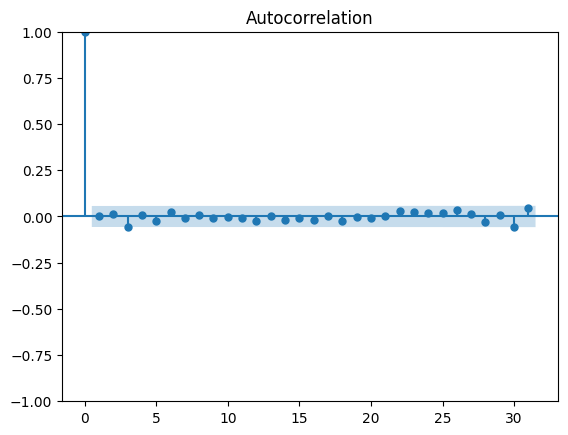

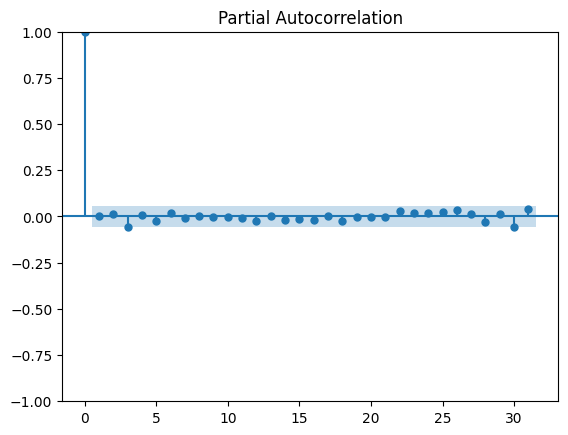

In [11]:
plot_acf(df['Close_Diff'])
plot_pacf(df['Close_Diff'])
plt.show()

Model Development

In [12]:
model = ARIMA(df['Close'], order=(1, 3, 3))
fitted_model = model.fit()
fitted_model.summary()

C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starti

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                 1187
Model:                 ARIMA(1, 3, 3)   Log Likelihood               -5078.582
Date:                Sun, 15 Mar 2026   AIC                          10167.165
Time:                        18:02:19   BIC                          10192.548
Sample:                             0   HQIC                         10176.733
                               - 1187                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9996      0.023    -43.575      0.000      -1.045      -0.955
ma.L1         -0.9987      0.239     -4.177      0.000      -1.467      -0.530
ma.L2         -1.0000      0.471     -2.125      0.034      -1.922      -0.078
ma.L3          0.9987      0.234      4.268      0.000       0.540       1.457
sigma2       305.9727     65.194      4.693      0.000     178.195     433.751
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               634.56
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               0.91   Skew:                            -0.05
Prob(H) (two-sided):                  0.35   Kurtosis:                         6.59
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [13]:
future_prices = fitted_model.forecast(steps=5)
print(future_prices)

1187    1380.944976
1188    1380.950678
1189    1381.193082
1190    1381.196369
1191    1381.436152
Name: predicted_mean, dtype: float64


C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [14]:
new_df = df[:-108]
model1 = ARIMA(new_df['Close'], order=(0, 1, 0))
fitted_model1 = model1.fit()
# print(fitted_model1.summary())
future_prices_new = fitted_model1.forecast(steps=7)
future_prices_new.index = df.index[-107:-100]
print(future_prices_new)


Date
2025-10-09    1384.800049
2025-10-10    1384.800049
2025-10-13    1384.800049
2025-10-14    1384.800049
2025-10-15    1384.800049
2025-10-16    1384.800049
2025-10-17    1384.800049
Name: predicted_mean, dtype: float64


C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given wit

In [ ]:
model_sarimax = SARIMAX(new_df['Close'], exog=new_df['Volume'], order=(0, 1, 0)).fit()
future_prices_sarimax = model_sarimax.forecast(steps=7, exog=df[-107:-100]['Volume'])
future_prices_sarimax.index = df.index[-107:-100]
plt.plot(df.index[-107:-100], df['Close'][-107:-100], label='Original Close')
plt.plot(df.index[-107:-100], future_prices_sarimax, label="Predicted Close")
plt.title("Model Performance Analysis - SARIMAX")
plt.legend()
plt.show()

plt.plot(df.index[-107:-100], df['Close'][-107:-100], label='Original Close')
plt.plot(df.index[-107:-100], future_prices_new, label="Predicted Close")
plt.title("Model Performance Analysis - ARIMA")
plt.legend()
plt.show()

plt.plot(df.index[-107:-100], df['Close'][-107:-100], label='Actual Price')
plt.plot(df.index[-107:-100], df['SMA'][-107:-100], label='5-Day SMA')
plt.title('SMA vs Actual Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

News Feed Ingestion

In [48]:
import feedparser
import pandas as pd
from transformers import pipeline

In [17]:
link = "https://news.google.com/rss/search?q=Reliance+Industries+stock&hl=en-IN&gl=IN&ceid=IN:en"
feed = feedparser.parse(link)
feed

{'bozo': False,
 'entries': [{'title': 'RIL shares fall over 2% post Q1 results; analysts say it missed estimates despite impressive numbers - Upstox',
   'title_detail': {'type': 'text/plain',
    'language': None,
    'base': 'https://news.google.com/rss/search?q=Reliance+Industries+stock&hl=en-IN&gl=IN&ceid=IN:en',
    'value': 'RIL shares fall over 2% post Q1 results; analysts say it missed estimates despite impressive numbers - Upstox'},
   'links': [{'rel': 'alternate',
     'type': 'text/html',
     'href': 'https://news.google.com/rss/articles/CBMi7AFBVV95cUxQWm4tbUticVZsclpKR0w5NXVtbzl3NG5KeG5YbEU3VzJzYmxoQzlFR1F1bS1MX3ZmenZyeHNtNzFITW12SkdaR19aa1JjTEd5eTJKVjI4TkZ1ZnhwN3VxZFJzdXN6c2RHMVB0RHk3WnhaajhLT0dlejM3d2tzcHN3ZmpINXVIVWxPcjV0Wm1Vd3ExSW5QSDJkMWxYSU05Z1k0RzVWc1FGRTN3UGpnQ1p4VlhDQk54OTVUQnR3YWxXNTFhTEtBWmliM1pfVnU3cGpHQ3MtLUpJbjhZTkFuZE8zQlR1RExWNnZCRzdCVQ?oc=5'}],
   'link': 'https://news.google.com/rss/articles/CBMi7AFBVV95cUxQWm4tbUticVZsclpKR0w5NXVtbzl3NG5KeG5YbEU3VzJzY

In [81]:
news = []
for item in feed.entries[:50]:
    # print(item)
    date = item.published
    headline = item.title
    news.append({'published': pd.to_datetime(date).date(),
                 'headline': headline})
news_df = pd.DataFrame(news)
news_df

,published,headline
0,2026-03-13,RIL shares fall over 2% post Q1 results; analy...
1,2026-03-11,Why Reliance Industries shares are gaining in ...
2,2026-03-12,Reliance Industries Share Price Rises After Te...
3,2026-03-14,Reliance Industries To Maruti Suzuki India: 3 ...
4,2026-03-13,Reliance Industries analysts do not see more d...
5,2026-03-11,Reliance remains mum even as Donald Trump anno...
6,2026-03-13,"Stock Picks Today: Reliance Industries, ABB In..."
7,2026-03-13,Strait of Hormuz blockade: Can it lift Relianc...
8,2026-03-11,Reliance Industries shares trade lower after T...
9,2026-03-12,Reliance Industries Share Price Rises 0.35% in...


Sentiment Analysis

In [82]:
sentiment_analyser = pipeline("sentiment-analysis", model="ProsusAI/finbert")

Device set to use cpu


In [83]:
results = sentiment_analyser(news_df['headline'].tolist())

news_df['label'] = [result['label'] for result in results]
news_df['score'] = [result['score'] for result in results]
news_df.head()

,published,headline,label,score
0,2026-03-13,RIL shares fall over 2% post Q1 results; analy...,negative,0.973436
1,2026-03-11,Why Reliance Industries shares are gaining in ...,positive,0.759048
2,2026-03-12,Reliance Industries Share Price Rises After Te...,neutral,0.395388
3,2026-03-14,Reliance Industries To Maruti Suzuki India: 3 ...,neutral,0.670122
4,2026-03-13,Reliance Industries analysts do not see more d...,neutral,0.534118


In [84]:
news_df['sentiment_value'] = news_df['label'].str.lower().map({'positive': 1, 'neutral': 0, 'negative': -1})
news_df['adjusted_score'] = news_df['score'] * news_df['sentiment_value']
# news_df['daily_sentiment'] = news_df['adjusted_score'].groupby(news_df['published']).mean()
news_df.head()

,published,headline,label,score,sentiment_value,adjusted_score
0,2026-03-13,RIL shares fall over 2% post Q1 results; analy...,negative,0.973436,-1,-0.973436
1,2026-03-11,Why Reliance Industries shares are gaining in ...,positive,0.759048,1,0.759048
2,2026-03-12,Reliance Industries Share Price Rises After Te...,neutral,0.395388,0,0.000000
3,2026-03-14,Reliance Industries To Maruti Suzuki India: 3 ...,neutral,0.670122,0,0.000000
4,2026-03-13,Reliance Industries analysts do not see more d...,neutral,0.534118,0,0.000000


In [88]:
daily_sentiment_df = news_df.groupby('published')['adjusted_score'].mean().reset_index()
daily_sentiment_df.head(10)

,published,adjusted_score
0,2025-11-20,0.930381
1,2025-11-25,0.915676
2,2026-01-06,-0.698470
3,2026-01-08,-0.835046
4,2026-01-19,-0.485315
5,2026-01-21,0.275633
6,2026-02-02,0.514962
7,2026-03-05,0.343015
8,2026-03-06,0.862479
9,2026-03-09,0.587501


Fusion Model

In [91]:
df = df.reset_index()
df.head()

Price,index,Date,Close,High,Low,Open,Volume,SMA,Error,Percentage,Close_Diff
0,0,2021-05-31,979.547546,993.785282,945.426862,953.112488,59124142,899.414460,80.133086,0.081806,29.699768
1,1,2021-06-01,983.447083,998.455648,973.290173,982.132103,28013832,900.033848,83.413235,0.084817,3.899536
2,2,2021-06-02,998.115540,1001.856347,978.051188,978.051188,24630162,901.356959,96.758580,0.096941,14.668457
3,3,2021-06-03,1001.924377,1020.220331,995.780410,1007.070776,23974257,903.175671,98.748706,0.098559,3.808838
4,4,2021-06-04,993.241211,1005.007723,990.407241,1004.259562,14468646,904.159619,89.081592,0.089688,-8.683167
